# Tutorial 01: Training Your First Model

In this tutorial, you will learn how to use `TorchTrainer` — Talos's built-in training engine — to fit a neural network on real data.

**Task**: Fit $y = \sin(x)$ on $[0,\, 2\pi]$ with a multi-layer perceptron (MLP).

What you will learn:

1. **Prepare data** — wrap numpy arrays into a Talos `Dataset` and split into train/test sets
2. **Build model** — create an MLP from the Talos model zoo
3. **Train** — run `TorchTrainer` for a fixed number of iterations
4. **Inspect history** — read training metrics from `trainer.history`
5. **Evaluate** — compare model predictions against ground truth

### Step 0: Setups
---

In [1]:
# Allow automatically using the newest version of your code
%load_ext autoreload
%autoreload 2

In [2]:
# Add necessary paths and import libraries
from utils import add_necessary_paths, check_torch
add_necessary_paths()

import utils.u01 as u
import talos as ta
import numpy as np

check_torch()
ta.set_seed()

 ! Cannot determine main file path in interactive mode.
:: PyTorch version: 2.6.0+cu124
:: CUDA is available. Number of CUDA devices: 7


DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "/pytorch/aten/src/ATen/cuda/CUDAContext.cpp":49, please report a bug to PyTorch. device=6, num_gpus=

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/sbh/miniconda3/envs/talos/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/sbh/miniconda3/env

### Step 1: Prepare data
---

Talos manages data through `ta.Dataset` — a lightweight wrapper around numpy arrays that provides splitting, sampling, and reporting.

Here we generate 200 evenly spaced points over $[0, 2\pi]$ and compute $y = \sin(x)$ as labels.

In [3]:
# Generate sin(x) data
X, Y = u.generate_data(n=200, seed=42)
dataset = ta.Dataset(X, Y, name='sin(x)')
dataset.report()

:: Dataset `sin(x)` (size: 200)
   - X: type=<class 'numpy.ndarray'>, shape=(200, 1)
   - Y: type=<class 'numpy.ndarray'>, shape=(200, 1)


In [4]:
# Split 80% training, 20% test (with shuffling)
train_set, test_set = dataset.split(4, 1, shuffle=True)
train_set.report()
test_set.report()

:: Dataset `sin(x) (1/2)` (size: 160)
   - X: type=<class 'numpy.ndarray'>, shape=(160, 1)
   - Y: type=<class 'numpy.ndarray'>, shape=(160, 1)
:: Dataset `sin(x) (2/2)` (size: 40)
   - X: type=<class 'numpy.ndarray'>, shape=(40, 1)
   - Y: type=<class 'numpy.ndarray'>, shape=(40, 1)


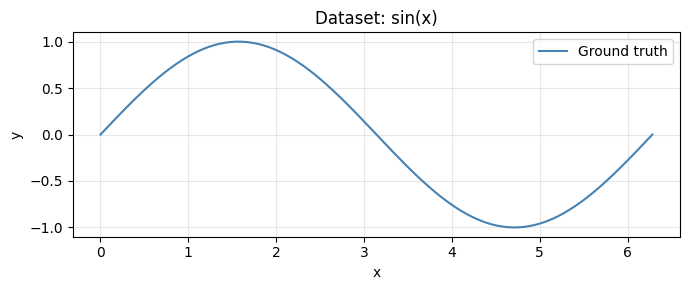

In [5]:
# Visualize training and test data
u.plot_predictions(X, Y, title='Dataset: sin(x)')

### Step 2: Build model
---

`ta.model.torch_zoo.MLP` creates a fully-connected network with configurable hidden layers and activation. Our network:

- **Input**: 1 feature ($x$)
- **Hidden**: two layers of 32 units with `tanh` activation
- **Output**: 1 value ($\hat{y}$)

In [6]:
# Instantiate an MLP with two hidden layers of 32 units
model = ta.model.torch_zoo.MLP(1, [32, 32], 1, activation='tanh')
print(model)

[talos.pytorch] torch=2.6.0+cu124; cuda=yes (v12.4); GPU 7/7="cuda:0"
MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Step 3: Train
---

`TorchTrainer` handles the full training loop: sampling batches, computing loss, running backpropagation, and recording metrics.

The minimal API requires just a model and a loss function:

In [7]:
# Create a trainer — Adam optimizer with MSE loss
trainer = u.get_trainer(model, loss_fn='mse', lr=1e-3, print_every=500)

In [8]:
# Train for 3000 iterations (full batch by default)
trainer.train(train_set, max_iterations=3000)

!! save_best=True has no effect without a validation set
>> Training started (max_iterations=3000)
>> Iter 500 | train/mse = 0.0134967
>> Iter 1000 | train/mse = 8.68742e-05
>> Iter 1500 | train/mse = 1.45173e-05
>> Iter 2000 | train/mse = 3.49268e-05
>> Iter 2500 | train/mse = 1.84254e-06
>> Iter 3000 | train/mse = 1.36096e-06
>> Training complete (iter 3000)


### Step 4: Inspect history
---

`trainer.history` records every metric logged during training. You can query it at any time — without interrupting training.

- `history.latest(key)` — most recent value
- `history.values(key)` / `history.iterations(key)` — full time series

In [9]:
# Read the final training MSE
final_mse = trainer.history.latest('train/mse')
print(f'Final train/mse: {final_mse:.6f}')

Final train/mse: 0.000001


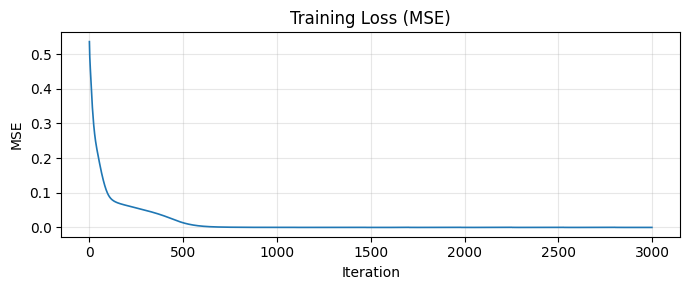

In [10]:
# Plot the training loss curve over all iterations
u.plot_loss_curve(trainer.history, key='train/mse',
                  title='Training Loss (MSE)')

### Step 5: Evaluate
---

After training, `model.predict(dataset)` runs inference and returns predictions as a numpy array. We compare predictions against the ground truth on the test set.

In [11]:
# Generate predictions on the test set
Y_pred = model.predict(test_set)

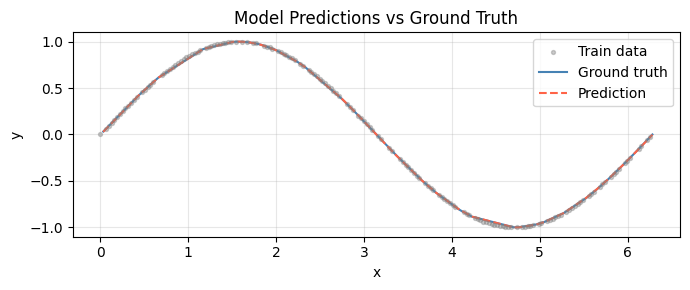

In [12]:
# Compare predictions against ground truth
u.plot_predictions(test_set.X, test_set.Y, Y_pred,
                   train_X=train_set.X, train_Y=train_set.Y,
                   title='Model Predictions vs Ground Truth')

### Takeaway

`TorchTrainer` encapsulates the entire training loop behind a clean, minimal interface:

```python
trainer = ta.TorchTrainer(model, optimizer='adam', loss_fn='mse', lr=1e-3)
trainer.train(train_set, max_iterations=3000)
```

The **model**, **data**, **loss function**, and **training history** are fully independent — you can inspect history at any point, swap models, or change loss functions without touching the rest.

In the **next tutorial**, we will add a validation set and early stopping to prevent overfitting automatically.